# qthermo tutorial: a two-qubit quantum thermal diode

This notebook takes one research question from a Hamiltonian to publishable
numbers, using the checks a referee would ask about along the way.

**The question.** Two coupled qubits with different frequencies sit between a
hot and a cold bath. Does heat flow more easily one way than the other (a
*thermal diode*), and what controls the effect?

Every cell runs in seconds. Conventions: $\hbar = k_B = 1$; heat currents are
positive when they flow *into* the system.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qthermo as qt

## 1. The machine

$H = \tfrac{\omega_1}{2}(-\sigma_z^1) + \tfrac{\omega_2}{2}(-\sigma_z^2)
+ \tfrac{J}{2}\,(\sigma_x^1\sigma_x^2 + \sigma_y^1\sigma_y^2 + \Delta\,\sigma_z^1\sigma_z^2)$,
with a bath on each qubit coupling through $\sigma_x$. Since $J \gg \gamma$ we use
**global** (Davies) baths, whose jump operators connect eigenstates of the full
coupled $H$. `qt.models.spin_chain` builds exactly this; the cell after builds
the same machine with `qt.build_model`, which is how you would describe your
own system.

In [2]:
diode = qt.models.spin_chain(2, omega=[1.0, 2.0], J=0.2, delta=3.0,
                             T_left=2.0, T_right=0.5, gamma=0.01,
                             master_equation="global")
print(diode.description)
print(diode.baths)

2-site XXZ chain (delta=3.0) between two baths
[Bath('left', kind=global, T=2, 8 jump operators), Bath('right', kind=global, T=0.5, 8 jump operators)]


In [3]:
X, Y, Z = qt.sigma_x, qt.sigma_y, qt.sigma_z
J, delta = 0.2, 3.0
by_hand = qt.build_model(
    local_H=[qt.qubit_hamiltonian(1.0), qt.qubit_hamiltonian(2.0)],
    interactions={(0, 1): 0.5 * J * (qt.embed(X, 0, [2, 2]) @ qt.embed(X, 1, [2, 2])
                                    + qt.embed(Y, 0, [2, 2]) @ qt.embed(Y, 1, [2, 2])
                                    + delta * qt.embed(Z, 0, [2, 2]) @ qt.embed(Z, 1, [2, 2]))},
    baths=[dict(name="left", site=0, coupling=X, T=2.0, gamma=0.01),
           dict(name="right", site=1, coupling=X, T=0.5, gamma=0.01)],
    master_equation="global")
print("same Hamiltonian as the model:", np.allclose(by_hand.H, diode.H))
print("same currents:", np.allclose(list(by_hand.analyze().currents.values()),
                                    list(diode.analyze().currents.values())))

same Hamiltonian as the model: True
same currents: True


## 2. Audit before trusting any number

`qt.audit` runs every consistency check: steady-state uniqueness, relaxation
time, second law, detailed balance of each bath against its declared
temperature, local-vs-global agreement, whether internal currents are
resolvable, and uncertainty-relation ratios.

In [4]:
print(qt.audit(diode))

[WARN]  local vs global: currents differ by up to 96%
          Results depend on the master equation; check which regime applies (local:
          coupling << bath rates; global: coupling >> bath rates).
[WARN]  internal currents: bond currents vanish identically in this global steady state
          The secular approximation removes the coherences that carry site-to-site
          currents. Totals per bath are fine; per-bond transport is not resolvable
          in this model.
[info]  relaxation time: 88.9 (populations)
[ok]    steady state: unique
[ok]    second law: entropy production rate 7.070e-04 >= 0
[ok]    uncertainty relation: 'left': TUR ratio 3.020 >= 2
[ok]    uncertainty relation: 'right': TUR ratio 3.020 >= 2
------------------------------------------------------------
0 error(s), 2 warning(s), 5 other checks


Two things to take from this. The local and global master equations
disagree here, which is expected at $J = 20\gamma$, and the global one is the
right choice. And under the global model the bond current between the qubits
cannot be resolved (the secular steady state is diagonal in $H$), so only the
per-bath totals below are meaningful.

## 3. Forward and reverse currents

Swap the temperatures and compare the magnitudes of the heat currents. The
rectification $R = (|J_\to| - |J_\leftarrow|)/(|J_\to| + |J_\leftarrow|)$ is zero for
a symmetric (linear) conductor.

In [5]:
def diode_currents(J=0.2, delta=3.0, gamma=0.01, master_equation="global"):
    common = dict(omega=[1.0, 2.0], J=J, delta=delta, gamma=gamma,
                  master_equation=master_equation)
    forward = qt.models.spin_chain(2, T_left=2.0, T_right=0.5, **common).analyze()
    reverse = qt.models.spin_chain(2, T_left=0.5, T_right=2.0, **common).analyze()
    return forward.current("left"), reverse.current("right")

def rectification(**kwargs):
    f, r = diode_currents(**kwargs)
    return (abs(f) - abs(r)) / (abs(f) + abs(r))

f, r = diode_currents()
print(f"hot bath on qubit 1 (w=1): J = {f:.4e}")
print(f"hot bath on qubit 2 (w=2): J = {r:.4e}")
print(f"rectification R = {rectification():+.3f}")

hot bath on qubit 1 (w=1): J = 4.7131e-04
hot bath on qubit 2 (w=2): J = 6.7661e-04
rectification R = -0.179


Heat flows about 18% more easily when the hot bath touches the
higher-frequency qubit ($R < 0$ with this labelling). The steady state behind these numbers is exact (a
linear solve, not long-time integration), and energy is conserved to machine
precision:

In [6]:
steady = diode.analyze()
print(steady.report())

bath                  T   J (into system)          -J/T
-------------------------------------------------------
left                  2      4.713080e-04   -2.3565e-04
right               0.5     -4.713080e-04    9.4262e-04
-------------------------------------------------------
sum                            -4.445e-18    7.0696e-04
entropy production rate: 7.0696e-04


## 4. What controls it: a parameter sweep

`qt.sweep` accepts any builder that returns a model, a cycle or a result, so
scanning a steady-state machine is one call. Here: rectification against the
$ZZ$ anisotropy $\Delta$, the nonlinearity of the coupling.

sweep over Delta  (21 points)
         value             |R|
------------------------------
        3.2000     1.92291e-01
        3.4000     2.05499e-01
        3.6000     2.18365e-01
        3.8000     2.30790e-01
        4.0000     2.42684e-01  <-- best
------------------------------
optimum: Delta = 4.0000, |R| = 2.42684e-01
optimum lies at the edge of the swept range: the true optimum may be outside it -- extend the range before reading anything into sensitivity


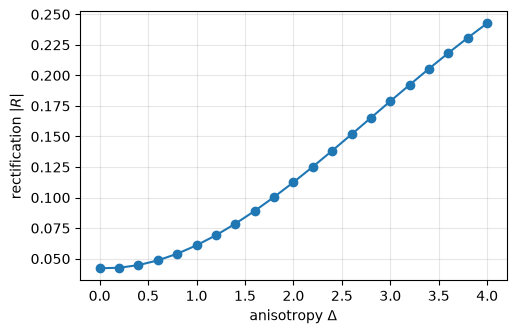

In [7]:
deltas = np.linspace(0.0, 4.0, 21)
scan = qt.sweep(lambda d: d, deltas, lambda d, _: abs(rectification(delta=d)),
                parameter="Delta", metric_name="|R|")
print(scan.report())
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(scan.values, scan.metrics, "o-")
ax.set_xlabel(r"anisotropy $\Delta$"); ax.set_ylabel(r"rectification $|R|$")
ax.grid(alpha=0.3); plt.show()

With an isotropic XX coupling ($\Delta = 0$) the diode barely works.
The $ZZ$ term, which makes the two-qubit spectrum anharmonic, is what drives
the rectification.

## 5. Would a different master equation change the conclusion?

The referee question. Sweep the bath coupling $\gamma$ at fixed $J$ and compare
local and global predictions. The local model is justified for
$\gamma \gg J$ and the global one for $\gamma \ll J$.

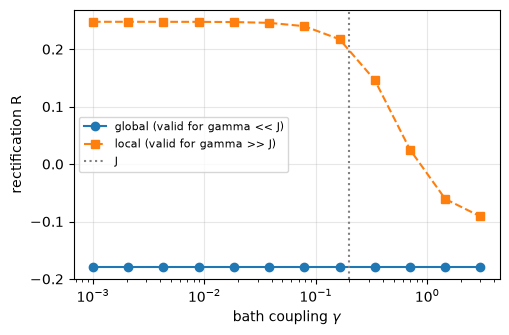

In [8]:
gammas = np.geomspace(1e-3, 3.0, 12)
local = [rectification(gamma=g, master_equation="local") for g in gammas]
glob = [rectification(gamma=g, master_equation="global") for g in gammas]
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.semilogx(gammas, glob, "o-", label="global (valid for gamma << J)")
ax.semilogx(gammas, local, "s--", label="local (valid for gamma >> J)")
ax.axvline(0.2, color="0.5", ls=":", label="J")
ax.set_xlabel(r"bath coupling $\gamma$"); ax.set_ylabel("rectification R")
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()

Read this carefully, because it changes the physics conclusion:

* The global prediction does not depend on $\gamma$ (every rate scales with it).
* Where the global model is valid ($\gamma \ll J$), the local model predicts
  rectification in the **opposite direction**.
* Only for $\gamma \gtrsim J$ does the local model agree on the sign, with a
  smaller magnitude. There the global model's secular approximation is the one
  that fails.

So the direction of this diode is a property of the master equation unless the
regime is stated. Near $\gamma \approx J$ neither model is controlled, and a
partially secular or Redfield treatment would be needed. A paper on this device
should say which regime it is in.

## 6. Fluctuations: how reliable is the diode?

The mean current is not the whole story. `current_statistics` gives the exact
noise of the heat current, and the thermodynamic uncertainty relation ratio
$(D/J^2)\,\dot\sigma$, which is at least 2 for any classical Markov process.

In [9]:
for label, T_left, T_right in (("forward", 2.0, 0.5), ("reverse", 0.5, 2.0)):
    m = qt.models.spin_chain(2, omega=[1.0, 2.0], J=0.2, delta=3.0, gamma=0.01,
                             T_left=T_left, T_right=T_right, master_equation="global")
    s = qt.current_statistics(m, "left", label=label)
    print(f"{label:>8}: J = {s.mean:+.3e}, Fano = {s.fano_factor:.3f}, "
          f"TUR ratio = {s.tur_ratio:.3f}")

 forward: J = +4.713e-04, Fano = 2.014, TUR ratio = 3.020
 reverse: J = -6.766e-04, Fano = 1.686, TUR ratio = 2.529


Both directions respect the classical bound, as they must: global Davies
dynamics with non-degenerate Bohr frequencies is a classical rate process.
A ratio below 2 would signal coherent transport; see
`examples/uncertainty_relation.py` for a machine where that happens.

## 7. Where next

| to study... | start from |
|---|---|
| refrigerators and virtual temperatures | `examples/absorption_refrigerator.py` |
| when local master equations fail | `examples/local_vs_global.py` |
| precision vs dissipation (TUR) | `examples/uncertainty_relation.py` |
| strong system-bath coupling | `examples/strong_coupling.py` |
| erasure and optimal protocols | `examples/landauer.py` |
| interacting Otto engines | `examples/coupled_otto.py` |
| operation-mode diagrams | `examples/operation_modes.py` |
| quantum batteries | `examples/quantum_battery.py` |

Every quantity above is defined precisely in `docs/physics.md`, and
`python -m qthermo.benchmarks` checks the package against published results.